### Architecture
In this experiment swin tranformer model is taken and applied on images with final head removal and single pawpularity output is added. In addition, strong resolution with strong augmentation is added, and FocalLoss is added 

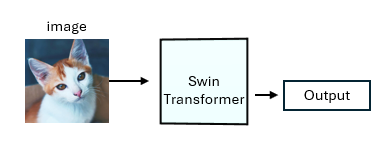

### Analysis
Swin models see the image as a set of tokens and uses multi‑head self‑attention to capture long‑range dependencies and global layout (how the pet, background, and other objects relate across the whole frame), whereas EfficientNet relies on local convolutions and pooling, which are less expressive for scene‑level images 


In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import os
import sys
sys.path.insert(0, os.path.abspath("../.."))

In [3]:
# imports and config
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import gc

gc.enable()

import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error

from src.config import EXP_CONFIGS
from src.utils import set_seed, save_config
from src.data import build_transforms, ImageOnlyDataset
from src.models import build_vision_backbone
from src.train import train_one_epoch_image, validate_image

main_folder = "../.."
data_csv = os.path.join(main_folder, "data", "train.csv")
img_folder = os.path.join(main_folder, "data", "train")
out_dir = os.path.join(main_folder, "outputs","extra", "exp3_swin_384_strong_FocalLoss")

df = pd.read_csv(data_csv)
cfg = EXP_CONFIGS["exp3"]
cfg["img_size"] = 384
cfg["name"] = "exp3_swin_384_strong_FocalLoss"
cfg["loss"] = "focal"
TARGET = "Pawpularity"
os.makedirs(out_dir, exist_ok=True)
save_config(cfg, out_dir)
set_seed(cfg["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from src.train import run_single_fold
import time

kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
oof_pred = np.zeros(len(df))
oof_true = df[TARGET].values
fold_index = np.full(len(df), -1, dtype=int)
fold_rmse = []

start_all = time.time()
for fold, (tr_idx, val_idx) in enumerate(kf.split(df), start=1):
    print(f"\n=== {cfg['name']}: Fold {fold} ===")
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)

    best_rmse, val_preds, val_targets, val_ids = run_single_fold(
        fold=fold,
        train_df=train_df,
        val_df=val_df,
        img_folder=img_folder,
        cfg=cfg,
        out_dir=out_dir,
        device=device,
        mode="image",
        tab_cols=None,
        workers=16,
        pin_memory=True,
        persistent_workers=True,
    )

    oof_pred[val_idx] = val_preds
    fold_index[val_idx] = fold
    fold_rmse.append(best_rmse)
    print(f"Fold {fold} best RMSE: {best_rmse:.4f}")


all_sec = time.time() - start_all
print(f"\nTotal training time: {int(all_sec//60)}m {int(all_sec%60)}s")
# final metrics + OOF with fold column
oof_rmse = root_mean_squared_error(oof_true, oof_pred)
fold_rmse = np.array(fold_rmse)
print(f"\nOOF RMSE: {oof_rmse:.4f}")
print(f"Fold RMSEs: {fold_rmse.tolist()}  Mean={fold_rmse.mean():.4f}  Std={fold_rmse.std():.4f}")

oof_df = pd.DataFrame({
    "Id": df["Id"],
    "fold": fold_index,      
    "ytrue": oof_true,
    "oof_pred": oof_pred,
})
oof_df["abs_err"] = (oof_df["ytrue"] - oof_df["oof_pred"]).abs()
oof_df.to_csv(os.path.join(out_dir, "oof_detail.csv"), index=False)
oof_df.sort_values("abs_err", ascending=False).head(50).to_csv(
    os.path.join(out_dir, "top50_errors.csv"), index=False
)

np.save(os.path.join(out_dir, "oof_pred.npy"), oof_pred)
np.save(os.path.join(out_dir, "fold_rmse.npy"), fold_rmse)
with open(os.path.join(out_dir, "metrics.txt"), "w") as f:
    f.write(f"OOF_RMSE: {oof_rmse:.4f}\n")
    f.write(f"Fold_RMSE: {fold_rmse.tolist()}\nMean: {fold_rmse.mean():.4f}\nStd: {fold_rmse.std():.4f}\n")



=== exp3_swin_384_strong_FocalLoss: Fold 1 ===
Epoch 1/10 | Fold 1 | Train[FOCAL]: Loss=0.1412 | ValRMSE: 19.2018
Epoch 2/10 | Fold 1 | Train[FOCAL]: Loss=0.1331 | ValRMSE: 19.9400
Epoch 3/10 | Fold 1 | Train[FOCAL]: Loss=0.1265 | ValRMSE: 20.4524
Epoch 4/10 | Fold 1 | Train[FOCAL]: Loss=0.1215 | ValRMSE: 21.5908
Epoch 5/10 | Fold 1 | Train[FOCAL]: Loss=0.1143 | ValRMSE: 20.7526
Epoch 6/10 | Fold 1 | Train[FOCAL]: Loss=0.1094 | ValRMSE: 21.0615
Early stopping at epoch 6
Fold 1 best RMSE: 19.2018

=== exp3_swin_384_strong_FocalLoss: Fold 2 ===
Epoch 1/10 | Fold 2 | Train[FOCAL]: Loss=0.1392 | ValRMSE: 19.4191
Epoch 2/10 | Fold 2 | Train[FOCAL]: Loss=0.1315 | ValRMSE: 19.8262
Epoch 3/10 | Fold 2 | Train[FOCAL]: Loss=0.1257 | ValRMSE: 20.0363
Epoch 4/10 | Fold 2 | Train[FOCAL]: Loss=0.1195 | ValRMSE: 21.1275
Epoch 5/10 | Fold 2 | Train[FOCAL]: Loss=0.1134 | ValRMSE: 21.3460
Epoch 6/10 | Fold 2 | Train[FOCAL]: Loss=0.1083 | ValRMSE: 23.0593
Early stopping at epoch 6
Fold 2 best RMSE: 19.4

In [ ]:
import pandas
df = pd.read_csv(out_dir+"/oof_detail.csv")
fold_rmse = []

for fold in range(1, 6):
    sub = df[df.fold == fold]
    rmse = ((sub.ytrue - sub.oof_pred)**2).mean() ** 0.5
    fold_rmse.append(rmse)
    print(f"Fold {fold} OOF RMSE: {rmse:.4f} (n={len(sub)})")

In [ ]:
from src.plot import plot_all_folds_history
plot_all_folds_history(out_dir, folds=[1,2,3,4,5], title_prefix="exp3_swin_256_strong")

In [ ]:
#  Inspect worst error rows

errors_path = os.path.join(out_dir, "top50_errors.csv")
err_df = pd.read_csv(errors_path)
err_df.head()


In [ ]:
import os
import pandas as pd
from src.plot import (
   plot_oof_true_pred_lines,
    show_images_grid,
)

# Load OOF detail and top-errors
oof_df = pd.read_csv(os.path.join(out_dir, "oof_detail.csv"))
err_df = pd.read_csv(os.path.join(out_dir, "top50_errors.csv"))

# Plots
plot_oof_true_pred_lines(oof_df, title_prefix="exp3_swin_256_strong")



